<a href="https://colab.research.google.com/github/yox19/Bioinformatics/blob/main/BIOINFORMATICS_COMPUTATIONAL_DRUG_DISCOVERY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 install library and Data loading

In [ ]:
# CHAMBLE DATA BASE
! pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.4 MB/s eta 0:00:00


In [ ]:
# import libraries

import pandas as pd
from chembl_webresource_client.new_client import new_client

Step 2: Search for Target protein
Target search for Acetylcholinesterase

In [ ]:

# Target search for coronavirus

target = new_client.target
target_query = target.search('acetylcholinesterase')
targets = pd.DataFrame.from_dict(target_query)
targets

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Drosophila melanogaster,Acetylcholinesterase,18.00,False,CHEMBL2242744,"[{'accession': 'P07140', 'component_descriptio...",SINGLE PROTEIN,7227
1,[],Homo sapiens,Acetylcholinesterase,16.00,False,CHEMBL220,"[{'accession': 'P22303', 'component_descriptio...",SINGLE PROTEIN,9606
2,[],Torpedo californica,Acetylcholinesterase,16.00,False,CHEMBL4780,"[{'accession': 'P04058', 'component_descriptio...",SINGLE PROTEIN,7787
3,[],Mus musculus,Acetylcholinesterase,16.00,False,CHEMBL3198,"[{'accession': 'P21836', 'component_descriptio...",SINGLE PROTEIN,10090
4,[],Rattus norvegicus,Acetylcholinesterase,16.00,False,CHEMBL3199,"[{'accession': 'P37136', 'component_descriptio...",SINGLE PROTEIN,10116
5,[],Electrophorus electricus,Acetylcholinesterase,16.00,False,CHEMBL4078,"[{'accession': 'O42275', 'component_descriptio...",SINGLE PROTEIN,8005
6,[],Bos taurus,Acetylcholinesterase,16.00,False,CHEMBL4768,"[{'accession': 'P23795', 'component_descriptio...",SINGLE PROTEIN,9913
7,[],Anopheles gambiae,Acetylcholinesterase,16.00,False,CHEMBL2046266,"[{'accession': 'Q869C3', 'component_descriptio...",SINGLE PROTEIN,7165
8,[],Bemisia tabaci,AChE2,16.00,False,CHEMBL2366409,"[{'accession': 'B3SST5', 'component_descriptio...",SINGLE PROTEIN,7038
9,[],Leptinotarsa decemlineata,Acetylcholinesterase,16.00,False,CHEMBL2366490,"[{'accession': 'Q27677', 'component_descriptio...",SINGLE PROTEIN,7539


Step 3 Human acetylcholinesterase only

In [ ]:
selected_target = targets.target_chembl_id[1]
selected_target

'CHEMBL220'

In [ ]:
# Extract bioactivity data for Human Acetylcholinesterase (CHEMBL220)
activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")


**activity_id**: This column serves as the unique identifier for each bioactivity entry, similar to what you might expect from a 'standard_id'.

**standard_value**: This is the numerical value representing the potency.

**standard_type**: This indicates the type of potency measurement (e.g., IC50, Ki).

**standard_units**: This specifies the units of the potency value (e.g., nM, uM).

In [ ]:
df = pd.DataFrame.from_dict(res)

In [ ]:
df

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.75
1,None,None,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.1
2,None,None,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,50.0
3,None,None,38902,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.3
4,None,None,41170,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9726,None,643508,27216797,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,411.0
9727,None,643509,27216800,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,395.0
9728,None,643510,27216803,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,625.0
9729,None,643511,27216806,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,320.0


In [ ]:
df.to_csv('acetylcholinesterase_01_bioactivity_data_raw.csv', index=False)

In [ ]:
# see content of CSV
! head acetylcholinesterase_01_bioactivity_data_raw.csv

action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
,,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholinesterase,B,,,BAO_0000190,BAO_0000357,single protein format,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,,,CHEMBL1148382,J Med Chem,2004.0,"{'bei': '19.61', 'le': '0.36', 'lle': '3.32', 'sei': '9.21'}",CHEMBL133897,,CHEMBL133897,6.12,0,http://www.op

Step 4 Handle missing data

In [ ]:
df2 = df[df.standard_value.notna()]
df2 = df2[df.canonical_smiles.notna()]
df2

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.75
1,None,None,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.1
2,None,None,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,50.0
3,None,None,38902,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.3
4,None,None,41170,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9726,None,643508,27216797,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,411.0
9727,None,643509,27216800,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,395.0
9728,None,643510,27216803,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,625.0
9729,None,643511,27216806,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,320.0


In [ ]:

len(df2.canonical_smiles.unique())

6898

In [ ]:
df2_nr = df2.drop_duplicates(['canonical_smiles'])
df2_nr

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.75
1,None,None,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.1
2,None,None,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,50.0
3,None,None,38902,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.3
4,None,None,41170,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9724,None,643506,27216791,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,5090.0
9726,None,643508,27216797,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,411.0
9727,None,643509,27216800,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,395.0
9728,None,643510,27216803,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,625.0


Step5 Data pre-processing of the bioactivity data

In [ ]:

selection = ['molecule_chembl_id','canonical_smiles','standard_value']
df3 = df2_nr[selection]
df3


,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0
...,...,...,...
9724,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.0
9726,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.0
9727,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.0
9728,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.0


In [ ]:
print(f"Shape of original DataFrame (df): {df.shape}")
print(f"Shape after dropping rows with missing standard_value or canonical_smiles (df2): {df2.shape}")
print(f"Shape after dropping duplicate canonical_smiles (df2_nr): {df2_nr.shape}")

Shape of original DataFrame (df): (9731, 46)
Shape after dropping rows with missing standard_value or canonical_smiles (df2): (8443, 46)
Shape after dropping duplicate canonical_smiles (df2_nr): (6898, 46)


In [ ]:
df3.to_csv('acetylcholinesterase_02_bioactivity_data_preprocessed.csv', index=False)


In [ ]:
# see CSV head
! head acetylcholinesterase_02_bioactivity_data_preprocessed.csv

molecule_chembl_id,canonical_smiles,standard_value
CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0
CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0
CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0
CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0
CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0
CHEMBL130112,CSc1nc(-c2ccc(C)cc2)nn1C(=O)N(C)c1ccccc1,2400.0
CHEMBL130098,CSc1nc(-c2ccc(Cl)cc2)nn1C(=O)N(C)C,100.0
CHEMBL337486,CCCCCCSc1nc(-c2ccc(Cl)cc2)nn1C(=O)N1CCOCC1,50000.0
CHEMBL336538,COc1ccc(-c2nc(SC)n(C(=O)N(C)C)n2)cc1,800.0


In [ ]:
! ls -1

acetylcholinesterase_01_bioactivity_data_raw.csv
acetylcholinesterase_02_bioactivity_data_preprocessed.csv
acetylcholinesterase_03_bioactivity_data_curated.csv
acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
acetylcholinesterase.zip
sample_data


Step 6 Labeling compounds as either being active, inactive or intermediate

In [ ]:
df4 = pd.read_csv('acetylcholinesterase_02_bioactivity_data_preprocessed.csv')

In [ ]:
bioactivity_threshold = []
for i in df4.standard_value:
  if float(i) >= 10000:
    bioactivity_threshold.append("inactive")
  elif float(i) <= 1000:
    bioactivity_threshold.append("active")
  else:
    bioactivity_threshold.append("intermediate")

In [ ]:
bioactivity_class = pd.Series(bioactivity_threshold, name='class')
df5 = pd.concat([df4, bioactivity_class], axis=1)
df5

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.00,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.00,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.00,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.00,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.00,active
...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.00,intermediate
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.00,active
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.00,active
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.00,active


In [ ]:
#Saves dataframe to CSV file
df5.to_csv('acetylcholinesterase_03_bioactivity_data_curated.csv', index=False)

In [ ]:

! zip acetylcholinesterase.zip *.csv

  adding: acetylcholinesterase_01_bioactivity_data_raw.csv (deflated 92%)
  adding: acetylcholinesterase_02_bioactivity_data_preprocessed.csv (deflated 80%)
  adding: acetylcholinesterase_03_bioactivity_data_curated.csv (deflated 82%)
  adding: acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv (deflated 96%)


In [ ]:
! ls -l

total 15896
-rw-r--r-- 1 root root 5792231 Mar  7 19:19 acetylcholinesterase_01_bioactivity_data_raw.csv
-rw-r--r-- 1 root root  505736 Mar  7 19:21 acetylcholinesterase_02_bioactivity_data_preprocessed.csv
-rw-r--r-- 1 root root  569085 Mar  7 19:23 acetylcholinesterase_03_bioactivity_data_curated.csv
-rw-r--r-- 1 root root 8363909 Mar  7 18:42 acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
-rw-r--r-- 1 root root 1033762 Mar  7 19:23 acetylcholinesterase.zip
drwxr-xr-x 1 root root    4096 Jan 16 14:24 sample_data


**Exploratory Data Analysis**

Step 6 Install conda and rdkit

In [ ]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
! conda install -c rdkit rdkit -y
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

--2026-03-07 19:36:06--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.32.241, 104.16.191.158, 2606:4700::6810:bf9e, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.32.241|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’

Miniconda3-py37_4.8 100%[===================>]  81.12M   289MB/s    in 0.3s    

2026-03-07 19:36:06 (289 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: / - done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - asn1crypto==1.3.0=py37_0
    - ca-certificates==2020.1.1=0
    - certifi==2019.11.28=py37_0
    - cffi==1.14.0=py37h2e261b9_0
    - chardet==3.0.4=py37_1003
    - conda-package-handling==1.6.0=p

In [ ]:
!pip install rdkit

     |████████████████████████████████| 29.5 MB 531 kB/s 


Step 7 Load bioactivity data

In [ ]:
! wget https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_03_bioactivity_data_curated.csv


--2026-03-07 19:48:53--  https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_03_bioactivity_data_curated.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 385924 (377K) [text/plain]
Saving to: ‘acetylcholinesterase_03_bioactivity_data_curated.csv.1’

acetylcholinesteras 100%[===================>] 376.88K  --.-KB/s    in 0.1s    

2026-03-07 19:48:53 (3.45 MB/s) - ‘acetylcholinesterase_03_bioactivity_data_curated.csv.1’ saved [385924/385924]



In [ ]:
import pandas as pd
df = pd.read_csv('acetylcholinesterase_03_bioactivity_data_curated.csv')
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.00,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.00,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.00,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.00,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.00,active
...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.00,intermediate
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.00,active
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.00,active
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.00,active


In [ ]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [ ]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [ ]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL133897,750.00,active,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1
1,CHEMBL336398,100.00,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1
2,CHEMBL131588,50000.00,inactive,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1
3,CHEMBL130628,300.00,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F
4,CHEMBL130478,800.00,active,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C
...,...,...,...,...
6893,CHEMBL6054495,5090.00,intermediate,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1
6894,CHEMBL5755069,411.00,active,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl
6895,CHEMBL5791030,395.00,active,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1
6896,CHEMBL5799857,625.00,active,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl


Steep 8 Calculate Lipinski descriptors

Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the druglikeness of compounds. Such druglikeness is based on the **Absorption**, **Distribution**, **Metabolism** and **Excretion** (**ADME**) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the Rule-of-Five or Lipinski's Rule.

The Lipinski's Rule stated the following:

Molecular weight < 500 Dalton

Octanol-water partition coefficient (LogP) < 5

Hydrogen bond donors < 5

Hydrogen bond acceptors < 10

In [ ]:
# import lib


import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

RuntimeError: module compiled against ABI version 0x1000009 but this version of numpy is 0x2000000

RuntimeError: module compiled against ABI version 0x1000009 but this version of numpy is 0x2000000

RuntimeError: module compiled against ABI version 0x1000009 but this version of numpy is 0x2000000

RuntimeError: module compiled against ABI version 0x1000009 but this version of numpy is 0x2000000

RuntimeError: module compiled against ABI version 0x1000009 but this version of numpy is 0x2000000

RuntimeError: module compiled against ABI version 0x1000009 but this version of numpy is 0x2000000

In [ ]:
import pandas as pd
df = pd.read_csv('acetylcholinesterase_03_bioactivity_data_curated.csv')
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.00,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.00,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.00,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.00,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.00,active
...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.00,intermediate
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.00,active
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.00,active
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.00,active


In [ ]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [ ]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [ ]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL133897,750.00,active,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1
1,CHEMBL336398,100.00,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1
2,CHEMBL131588,50000.00,inactive,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1
3,CHEMBL130628,300.00,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F
4,CHEMBL130478,800.00,active,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C
...,...,...,...,...
6893,CHEMBL6054495,5090.00,intermediate,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1
6894,CHEMBL5755069,411.00,active,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl
6895,CHEMBL5791030,395.00,active,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1
6896,CHEMBL5799857,625.00,active,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl


Step 9 Calculate descriptors

In [ ]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [ ]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,312.33,2.80,0.00,6.00
1,376.91,4.55,0.00,5.00
2,426.85,5.36,0.00,5.00
3,404.85,4.71,0.00,5.00
4,346.33,3.10,0.00,6.00
...,...,...,...,...
6893,485.41,3.90,2.00,4.00
6894,378.94,4.88,2.00,4.00
6895,407.00,5.58,1.00,4.00
6896,424.99,5.53,1.00,4.00


The Lipinski's Rule stated the following:

Molecular weight < 500 Dalton - MW

Octanol-water partition coefficient (LogP) < 5 - Solubility

Hydrogen bond donors < 5 - NumHDonors

Hydrogen bond acceptors < 10 - NumHAcceptors

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski



1.   List item
2.   List item



Step 10 Combine DataFrames

In [ ]:
# combine 2 df
df_combined = pd.concat([df,df_lipinski], axis=1)
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.00,active,312.33,2.80,0.00,6.00
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.00,active,376.91,4.55,0.00,5.00
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.00,inactive,426.85,5.36,0.00,5.00
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.00,active,404.85,4.71,0.00,5.00
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.00,active,346.33,3.10,0.00,6.00
...,...,...,...,...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.00,intermediate,485.41,3.90,2.00,4.00
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.00,active,378.94,4.88,2.00,4.00
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.00,active,407.00,5.58,1.00,4.00
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.00,active,424.99,5.53,1.00,4.00


Step11 Convert IC50 to pIC50

In [ ]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

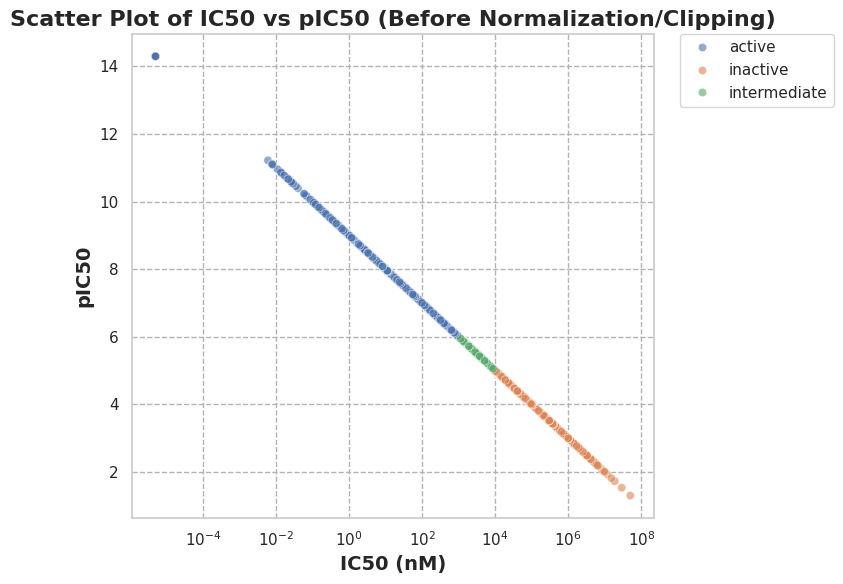

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_pIC50_from_raw(value):
    molar = value * (10**-9) # Converts nM to M
    # Handle cases where molar is zero or results in non-finite log
    if molar <= 0:
        return np.nan # Return NaN for non-positive concentrations
    return -np.log10(molar)

# Create a copy of df_combined for plotting to avoid modifying the original DataFrame
df_plot = df_combined.copy()

# Apply the pIC50 calculation to the original standard_value
df_plot['pIC50_calculated'] = df_plot['standard_value'].apply(calculate_pIC50_from_raw)

# Filter out any non-finite pIC50_calculated values (e.g., from 0 or negative IC50s)
df_plot_filtered = df_plot.replace([np.inf, -np.inf], np.nan).dropna(subset=['pIC50_calculated'])


plt.figure(figsize=(8, 6))
sns.scatterplot(x='standard_value', y='pIC50_calculated', data=df_plot_filtered, hue='class', alpha=0.6)
plt.xscale('log') # IC50 values often span several orders of magnitude, so a log scale is appropriate
plt.xlabel('IC50 (nM)', fontsize=14, fontweight='bold')
plt.ylabel('pIC50', fontsize=14, fontweight='bold')
plt.title('Scatter Plot of IC50 vs pIC50 (Before Normalization/Clipping)', fontsize=16, fontweight='bold')
plt.grid(True, which="both", ls="--", c=".7")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

In [ ]:
df_combined.standard_value.describe()

,standard_value
count,6898.00
mean,99238.81
std,872003.92
min,0.00
25%,160.00
50%,2420.00
75%,16265.00
max,49600000.00


In [ ]:

-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [ ]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [ ]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

In [ ]:
# We will first apply the norm_value() function so that the values in the standard_value column is normalized.
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.33,2.80,0.00,6.00,750.00
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.91,4.55,0.00,5.00,100.00
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.85,5.36,0.00,5.00,50000.00
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.85,4.71,0.00,5.00,300.00
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.33,3.10,0.00,6.00,800.00
...,...,...,...,...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,intermediate,485.41,3.90,2.00,4.00,5090.00
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,378.94,4.88,2.00,4.00,411.00
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,407.00,5.58,1.00,4.00,395.00
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,424.99,5.53,1.00,4.00,625.00


In [ ]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,6898.00
mean,99238.81
std,872003.92
min,0.00
25%,160.00
50%,2420.00
75%,16265.00
max,49600000.00


In [ ]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.33,2.80,0.00,6.00,6.12
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.91,4.55,0.00,5.00,7.00
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.85,5.36,0.00,5.00,4.30
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.85,4.71,0.00,5.00,6.52
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.33,3.10,0.00,6.00,6.10
...,...,...,...,...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,intermediate,485.41,3.90,2.00,4.00,5.29
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,378.94,4.88,2.00,4.00,6.39
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,407.00,5.58,1.00,4.00,6.40
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,424.99,5.53,1.00,4.00,6.20


In [ ]:
df_final.pIC50.describe()

,pIC50
count,6898.00
mean,inf
std,NaN
min,1.30
25%,4.79
50%,5.62
75%,6.80
max,inf


In [ ]:
import numpy as np

df_final_filtered = df_final[~np.isinf(df_final['pIC50'])]
df_final_filtered

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.33,2.80,0.00,6.00,6.12
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.91,4.55,0.00,5.00,7.00
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.85,5.36,0.00,5.00,4.30
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.85,4.71,0.00,5.00,6.52
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.33,3.10,0.00,6.00,6.10
...,...,...,...,...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,intermediate,485.41,3.90,2.00,4.00,5.29
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,378.94,4.88,2.00,4.00,6.39
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,407.00,5.58,1.00,4.00,6.40
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,424.99,5.53,1.00,4.00,6.20


In [ ]:
df_final_filtered.pIC50.describe()

,pIC50
count,6897.00
mean,5.81
std,1.55
min,1.30
25%,4.79
50%,5.62
75%,6.80
max,14.30


In [ ]:
df_final.to_csv('acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv')

Step 12 Removing the 'intermediate' bioactivity class

In [ ]:
# Here, we will be removing the intermediate class from our data set.
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.33,2.80,0.00,6.00,6.12
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.91,4.55,0.00,5.00,7.00
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.85,5.36,0.00,5.00,4.30
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.85,4.71,0.00,5.00,6.52
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.33,3.10,0.00,6.00,6.10
...,...,...,...,...,...,...,...,...
6890,CHEMBL6040839,COc1cc(N)c(I)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,484.42,5.14,1.00,4.00,6.52
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,378.94,4.88,2.00,4.00,6.39
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,407.00,5.58,1.00,4.00,6.40
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,424.99,5.53,1.00,4.00,6.20


In [ ]:
df_2class.to_csv('acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv')

Step 13 Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors

In [ ]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

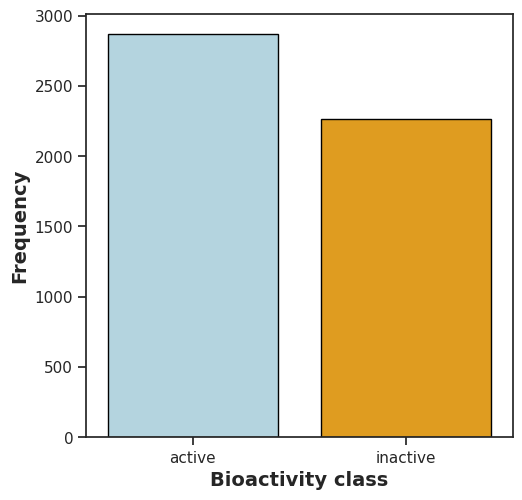

In [ ]:
# Frequency plot of the 2 bioactivity classes
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_2class, edgecolor='black', palette=['lightblue', 'orange'])

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

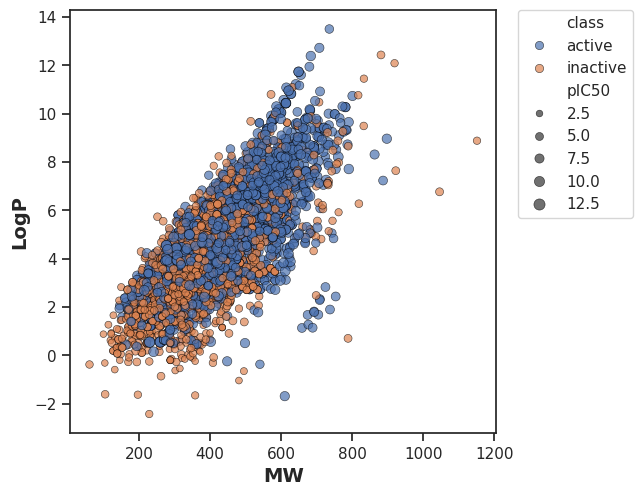

In [ ]:
# Scatter plot of MW versus LogP
plt.figure(figsize=(5.5, 5.5))

# Filter out infinite pIC50 values before plotting
df_2class_finite_pIC50 = df_2class[np.isfinite(df_2class['pIC50'])]
sns.scatterplot(x='MW', y='LogP', data=df_2class_finite_pIC50, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

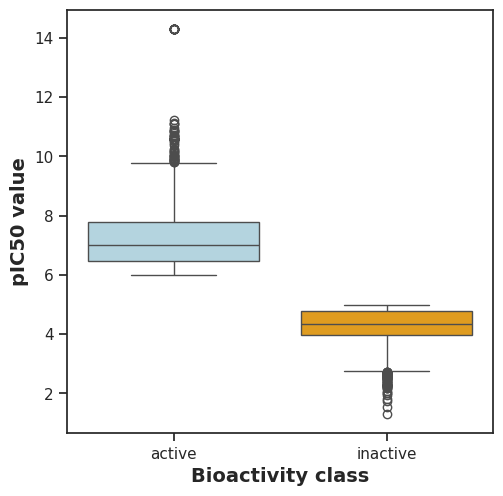

In [ ]:
# Box plots
# pIC50 value
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data = df_2class, palette=['lightblue', 'orange'])

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

Step 14 Statistical analysis | Mann-Whitney U Test

In [ ]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df = df_2class[selection]
  active = df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_2class[selection]
  inactive = df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

  # interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,6500550.00,0.00,0.05,Different distribution (reject H0)


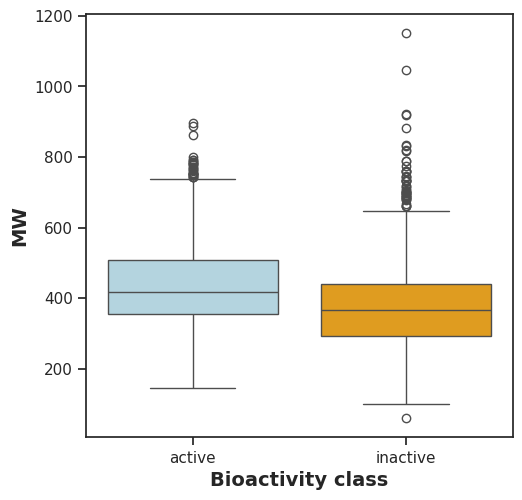

In [ ]:
# MW

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data = df_2class, palette=['lightblue', 'orange'])

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,4214939.50,0.00,0.05,Different distribution (reject H0)


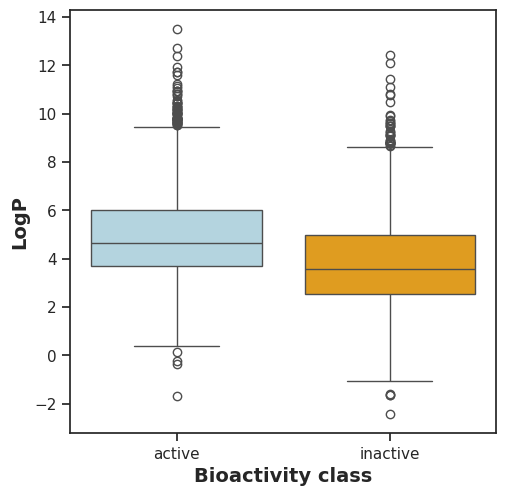

In [ ]:
# LogP
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'LogP', data = df_2class, palette=['lightblue', 'orange'])

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

Statistical analysis | Mann-Whitney U Test

In [ ]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,4326735.00,0.00,0.05,Different distribution (reject H0)


NumHDonors

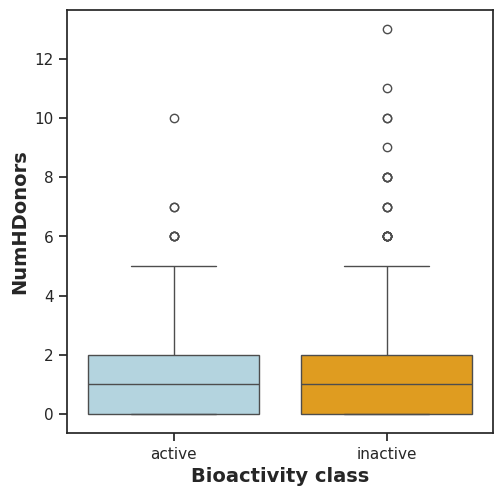

In [ ]:
#
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHDonors', data = df_2class, palette=['lightblue', 'orange'])

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

NumHAcceptors

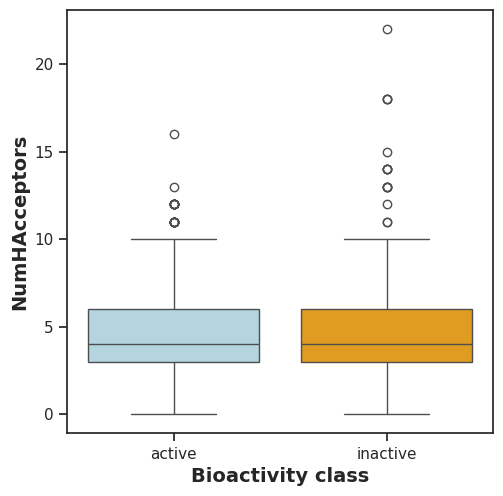

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df_2class, palette=['lightblue', 'orange'])

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,3497551.00,0.00,0.05,Different distribution (reject H0)


Interpretation of Statistical Results

**Box Plots**

**pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed **statistically** **significant** **difference**, which is to be expected since threshold values (IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives, corresponding to pIC50 > 6 = Actives and pIC50 < 5 = Inactives) were used to define actives and inactives.

Lipinski's descriptors
A**l**l of the **4 Lipinski's descriptors** exhibited **statistically** **significant** **difference** between the **actives** and **inactives**.

In [ ]:
# Zip files
! zip -r results.zip . -i *.csv *.pdf

  adding: mannwhitneyu_LogP.csv (deflated 9%)
  adding: plot_MW_vs_LogP.pdf (deflated 2%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 10%)
  adding: plot_ic50.pdf (deflated 35%)
  adding: acetylcholinesterase_03_bioactivity_data_curated.csv (deflated 82%)
  adding: plot_NumHDonors.pdf (deflated 38%)
  adding: mannwhitneyu_pIC50.csv (deflated 11%)
  adding: plot_bioactivity_class.pdf (deflated 38%)
  adding: acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv (deflated 96%)
  adding: plot_LogP.pdf (deflated 37%)
  adding: acetylcholinesterase_01_bioactivity_data_raw.csv (deflated 92%)
  adding: acetylcholinesterase_02_bioactivity_data_preprocessed.csv (deflated 80%)
  adding: mannwhitneyu_MW.csv (deflated 9%)
  adding: plot_MW.pdf (deflated 38%)
  adding: acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv (deflated 75%)
  adding: acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv (deflated 76%)
  adding: plot_NumHAcceptors.pdf (deflated 39%)


**Descriptor Calculation and Dataset Preparation**

we will be calculating molecular descriptors that are essentially quantitative description of the compounds in the dataset. Finally, we will be preparing this into a dataset for subsequent model building

Step 15 Download PaDEL-Descriptor

In [ ]:
! wget https://github.com/dataprofessor/bioinformatics/raw/master/padel.zip
! wget https://github.com/dataprofessor/bioinformatics/raw/master/padel.sh



--2026-03-07 20:16:58--  https://github.com/dataprofessor/bioinformatics/raw/master/padel.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-07 20:16:59 ERROR 404: Not Found.

--2026-03-07 20:16:59--  https://github.com/dataprofessor/bioinformatics/raw/master/padel.sh
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-07 20:17:00 ERROR 404: Not Found.



In [ ]:
! unzip padel.zip

unzip:  cannot find or open padel.zip, padel.zip.zip or padel.zip.ZIP.


Step 16 Load bioactivity data

Download the curated ChEMBL bioactivity data that has been pre-processed from Parts 1 and 2 of this Bioinformatics Project series. Here we will be using the **bioactivity_data_3class_pIC50.csv** file that essentially contain the pIC50 values that we will be using for building a regression model.

In [ ]:
! wget https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv


--2026-03-07 20:17:32--  https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 655414 (640K) [text/plain]
Saving to: ‘acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv.1’

acetylcholinesteras 100%[===================>] 640.05K  --.-KB/s    in 0.1s    

2026-03-07 20:17:32 (4.69 MB/s) - ‘acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv.1’ saved [655414/655414]



In [ ]:
import pandas as pd

In [ ]:
df3 = pd.read_csv('acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv')
df3

,Unnamed: 0,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.33,2.80,0.00,6.00,6.12
1,1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.91,4.55,0.00,5.00,7.00
2,2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.85,5.36,0.00,5.00,4.30
3,3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.85,4.71,0.00,5.00,6.52
4,4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.33,3.10,0.00,6.00,6.10
...,...,...,...,...,...,...,...,...,...
6893,6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,intermediate,485.41,3.90,2.00,4.00,5.29
6894,6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,378.94,4.88,2.00,4.00,6.39
6895,6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,407.00,5.58,1.00,4.00,6.40
6896,6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,424.99,5.53,1.00,4.00,6.20


In [ ]:
selection = ['canonical_smiles','molecule_chembl_id']
df3_selection = df3[selection]
df3_selection.to_csv('molecule.smi', sep='\t', index=False, header=False)

In [ ]:
! cat molecule.smi | head -5

CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1	CHEMBL133897
O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1	CHEMBL336398
CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1	CHEMBL131588
O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F	CHEMBL130628
CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C	CHEMBL130478


In [ ]:
! cat molecule.smi | wc -l

6898


Step 17 Calculate fingerprint descriptors
Calculate PaDEL descriptors

### Step 18: Calculate Additional RDKit Molecular Descriptors

We will now calculate additional molecular descriptors using RDKit. These descriptors capture various chemical properties of the molecules, which can be useful for quantitative structure-activity relationship (QSAR) modeling.

The `df_all_descriptors` DataFrame now contains the molecular descriptors calculated using RDKit, in addition to the `molecule_chembl_id`, `canonical_smiles`, `class`, and `pIC50` values. This will be the foundation for building our machine learning model.

**Regression Models with Random Forest**

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [ ]:
! wget https://github.com/dataprofessor/data/raw/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv

--2026-03-07 20:20:42--  https://github.com/dataprofessor/data/raw/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv [following]
--2026-03-07 20:20:43--  https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8363909 (8.0M) [text/plain]
Saving to: ‘acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubche

In [ ]:
df = pd.read_csv('acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')
df

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.12
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.00
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4.30
3,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.52
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4690,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.61
4691,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.60
4692,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.42
4693,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.46


Step 18 3. Input features
The Acetylcholinesterase data set contains 881 input features and 1 output variable (pIC50 values).

Step 18 3.1 Input features

In [ ]:
X = df.drop('pIC50', axis=1)
X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4690,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4691,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4692,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4693,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


Step 18 3.2 Output features

In [ ]:
Y = df.pIC50
Y

,pIC50
0,6.12
1,7.00
2,4.30
3,6.52
4,6.10
...,...
4690,5.61
4691,5.60
4692,5.42
4693,5.46


Step 18 3.3. Let's examine the data dimension

In [ ]:
X.shape

(4695, 137)

In [ ]:
Y.shape

(4695,)

Step 18 3.4. Remove low variance features

In [ ]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)

In [ ]:
X.shape

(4695, 137)

Step 19 Data split (80/20 ratio)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, Y_train.shape

((3756, 137), (3756,))

In [ ]:
X_test.shape, Y_test.shape

((939, 137), (939,))

Step 21 Building a Regression Model using Random Forest

In [ ]:
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)
r2 = model.score(X_test, Y_test)
r2

0.520615569530291

In [ ]:
Y_pred = model.predict(X_test)

Step 22 Scatter Plot of Experimental vs Predicted pIC50 Values

<function matplotlib.pyplot.show(close=None, block=None)>

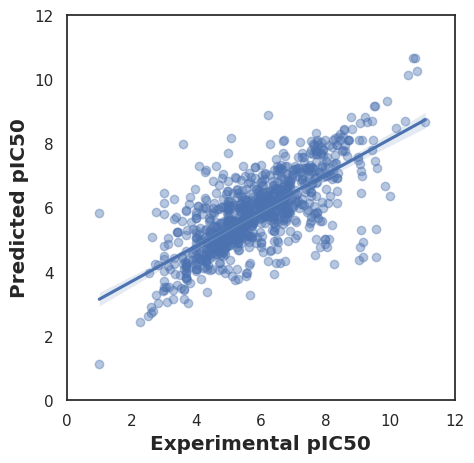

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True)
sns.set_style("white")

ax = sns.regplot(x=Y_test, y=Y_pred, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.show

**Final Task Comparing Regressors**

we will be comparing several ML algorithms for build regression models of acetylcholinesterase inhibitors.

Step 23 1. Import libraries

In [ ]:
!pip install --upgrade pip
!pip install lazypredict
!pip install scikit-learn==0.24.2

     |████████████████████████████████| 2.1 MB 4.1 MB/s 
  Attempting uninstall: pip
    Found existing installation: pip 20.0.2
    Uninstalling pip-20.0.2:
      Successfully uninstalled pip-20.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.8/24.8 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 20.7 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 13.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.0.2
    Uninstalling scikit-learn-1.0.2:
      Successfully uninstalled scikit-learn-1.0.2
ERROR: Operation cancelled by user
^C


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

Step 23 2. Load the data set

In [ ]:
! wget https://github.com/dataprofessor/data/raw/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv

--2026-03-07 20:37:58--  https://github.com/dataprofessor/data/raw/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv [following]
--2026-03-07 20:37:58--  https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8363909 (8.0M) [text/plain]
Saving to: ‘acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubche

In [ ]:
df = pd.read_csv('acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [ ]:

X = df.drop('pIC50', axis=1)
Y = df.pIC50

Step 23 3. Data pre-processing

In [ ]:
# Examine X dimension
X.shape

(4695, 881)

In [ ]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)
X.shape

(4695, 137)

In [ ]:
# Perform data splitting using 80/20 ratio
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Step 23 4. Compare ML algorithms

In [ ]:

# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None)
models_train,predictions_train = clf.fit(X_train, X_train, Y_train, Y_train)
models_test,predictions_test = clf.fit(X_train, X_test, Y_train, Y_test)

  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003426 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 411
[LightGBM] [Info] Number of data points in the train set: 3756, number of used features: 137
[LightGBM] [Info] Start training from score 5.814494
'tuple' object has no attribute '__name__'
Invalid Regressor(s)


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004451 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 411
[LightGBM] [Info] Number of data points in the train set: 3756, number of used features: 137
[LightGBM] [Info] Start training from score 5.814494


In [ ]:
# Performance table of the training set (80% subset)
predictions_train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreeRegressor,0.86,0.86,0.57,0.18
DecisionTreeRegressor,0.86,0.86,0.57,0.16
ExtraTreesRegressor,0.86,0.86,0.57,8.31
GaussianProcessRegressor,0.86,0.86,0.57,6.98
RandomForestRegressor,0.82,0.83,0.64,7.17
XGBRegressor,0.82,0.83,0.65,0.40
BaggingRegressor,0.80,0.81,0.67,0.61
MLPRegressor,0.76,0.77,0.75,10.50
HistGradientBoostingRegressor,0.67,0.69,0.87,1.29


In [ ]:
# Performance table of the test set (20% subset)
predictions_test

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
HistGradientBoostingRegressor,0.46,0.54,1.06,1.30
RandomForestRegressor,0.44,0.52,1.08,6.37
LGBMRegressor,0.44,0.52,1.08,0.36
XGBRegressor,0.44,0.52,1.08,0.34
BaggingRegressor,0.41,0.49,1.11,0.59
NuSVR,0.39,0.48,1.12,1.63
SVR,0.39,0.48,1.12,2.06
KNeighborsRegressor,0.37,0.46,1.14,0.19
MLPRegressor,0.36,0.45,1.15,9.81


Step 23 5. Data visualization of model performance

[(0.0, 1.0)]

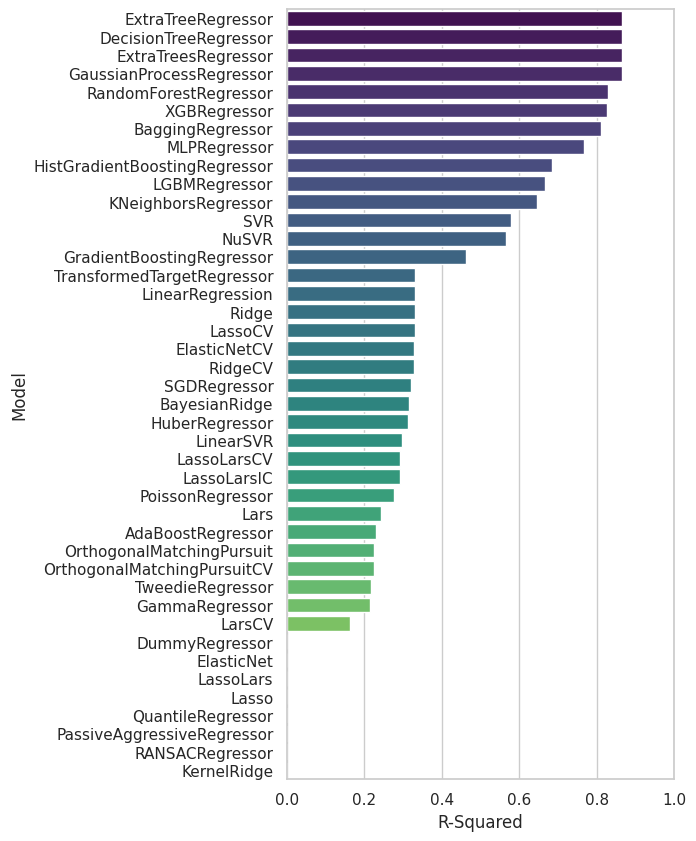

In [ ]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="R-Squared", data=predictions_train, palette='viridis')
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

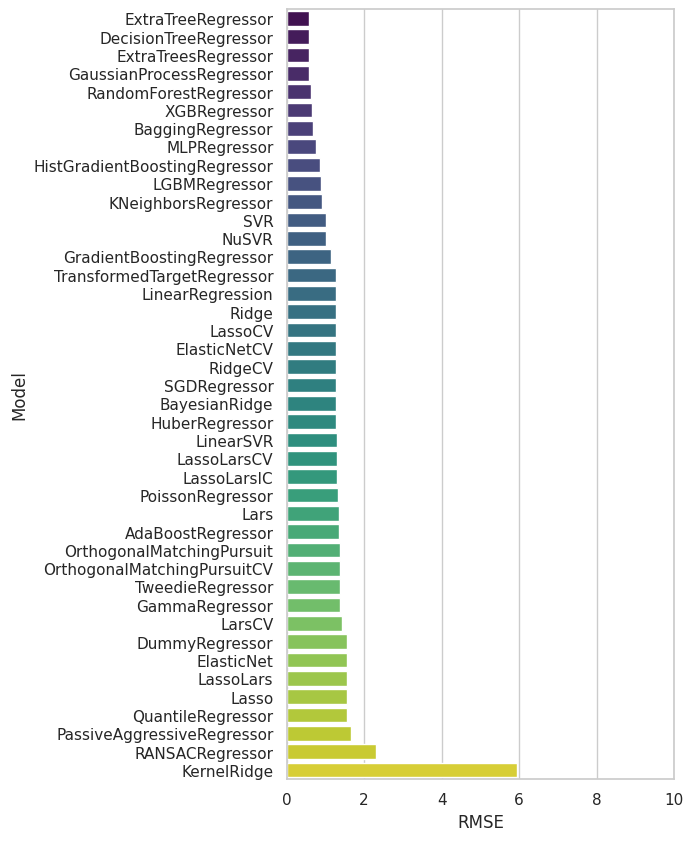

In [ ]:
# Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="RMSE", data=predictions_train, palette='viridis')
ax.set(xlim=(0, 10))

[(0.0, 10.0)]

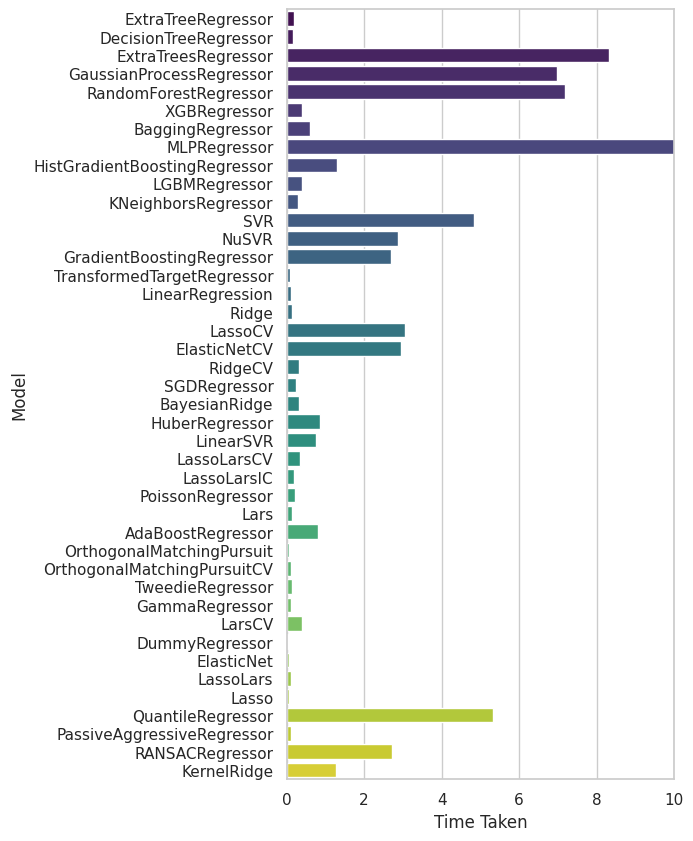

In [ ]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="Time Taken", data=predictions_train, palette='viridis')
ax.set(xlim=(0, 10))

# Task
**Task:** Summarize the core bioinformatics concepts introduced in this project, including target search, bioactivity data, Lipinski's Rule of Five, and pIC50 calculation, providing simplified explanations.

**Summary of Bioinformatics Introduction Concepts:**

This project delves into various fundamental bioinformatics concepts essential for drug discovery, particularly focusing on identifying potential drug candidates for Acetylcholinesterase, a target protein relevant to diseases like Alzheimer's.

1.  **Target Search (e.g., for Acetylcholinesterase):** The initial step in drug discovery involves identifying a biological target, typically a protein, whose activity can be modulated by a drug to achieve a therapeutic effect. In this project, the ChEMBL database is used to search for the target protein "Acetylcholinesterase". This search returns information about various organisms' acetylcholinesterase, from which "Homo sapiens" (human) is selected as the primary target (identified by `CHEMBL220`).

2.  **Bioactivity Data:** Once a target is identified, bioactivity data is retrieved. This data describes how strongly a chemical compound interacts with a biological target. Key components of bioactivity data often include:
    *   **activity_id:** A unique identifier for each bioactivity entry.
    *   **standard_value:** The numerical value representing the potency of the compound (e.g., concentration required to inhibit 50% of the target's activity).
    *   **standard_type:** The type of potency measurement (e.g., IC50 - half maximal inhibitory concentration, which measures how much of a particular inhibitor is needed to inhibit a given biological process by half).
    *   **standard_units:** The units of the potency value (e.g., nM for nanomolar, uM for micromolar).
    *   **canonical_smiles:** A standardized way to represent the chemical structure of the compound as a string.
    The project preprocesses this raw data by handling missing values in `standard_value` and `canonical_smiles` and removing duplicate entries based on `canonical_smiles`. Compounds are then categorized into 'active' (IC50 < 1000 nM), 'intermediate' (1000 nM <= IC50 <= 10000 nM), or 'inactive' (IC50 > 10000 nM) based on their `standard_value`.

3.  **Lipinski's Rule of Five:** This is a set of empirical rules of thumb used in drug discovery to evaluate the "druglikeness" of a chemical compound. It predicts whether a compound is likely to have good oral bioavailability (how well it's absorbed into the body and reaches its target). The rules state that for a drug to be orally active, it should generally have:
    *   **Molecular Weight (MW) < 500 Dalton:** Smaller molecules tend to be absorbed more easily.
    *   **Octanol-water partition coefficient (LogP) < 5:** Measures a molecule's lipophilicity (fat-loving nature). A LogP value less than 5 suggests good permeability across cell membranes.
    *   **Hydrogen bond donors (NumHDonors) < 5:** Refers to the number of N-H or O-H bonds. Fewer hydrogen bond donors can improve permeability.
    *   **Hydrogen bond acceptors (NumHAcceptors) < 10:** Refers to the number of nitrogen or oxygen atoms. Fewer hydrogen bond acceptors can also improve permeability.
    These descriptors are calculated for each compound using RDKit.

4.  **pIC50 Calculation:** To convert raw IC50 values into a more convenient and normally distributed scale, pIC50 values are calculated. The formula for pIC50 is `-log10(molar concentration)`.
    *   First, IC50 values (typically in nM) are converted to molar (M) by multiplying by `10^-9`.
    *   Then, the negative logarithm (base 10) of this molar concentration is taken.
    *   Values are often normalized (e.g., capping very high IC50 values to avoid extremely low pIC50s) before this transformation.
    A higher pIC50 value indicates greater potency (lower IC50). This transformation is crucial for downstream statistical analysis and machine learning models, as it often results in a more linear relationship with other molecular properties.

## Summarize Bioinformatics Introduction Concepts

### Subtask:
Review the relevant text cells and code explanations to summarize the core bioinformatics concepts introduced in this project, such as target search, bioactivity data, Lipinski's Rule of Five, and pIC50 calculation, providing simplified explanations where necessary.


### Summarize Bioinformatics Introduction Concepts

#### Target Search

In drug discovery, a **target** is typically a protein or a gene that a drug is designed to interact with. The process of **Target Search** involves identifying a specific biological target that is associated with a disease and then retrieving relevant information about it from a database.

In this project, the `chembl_webresource_client` library was used to search the ChEMBL database for the protein **Acetylcholinesterase**. This protein was chosen as the target because it is an important target in the treatment of Alzheimer's disease. The search returned various entries for Acetylcholinesterase from different organisms, and specifically, the human Acetylcholinesterase (CHEMBL220) was selected for further analysis, focusing on its bioactivity data.


#### Bioactivity Data

**Bioactivity data** refers to measurements of how a substance (like a drug compound) affects a biological system. In the context of drug discovery, it often quantifies the strength of the interaction between a chemical compound and its biological target (e.g., a protein). Common types of bioactivity measurements include IC50, EC50, Ki, and Kd.

In this project, **IC50 (Half Maximal Inhibitory Concentration)** values were primarily used. IC50 represents the concentration of a drug that is required for 50% inhibition of a biological process or component. A lower IC50 value indicates a more potent compound.

The project extracted bioactivity data from the ChEMBL database for the selected target (human Acetylcholinesterase). The key information extracted included:
- **`activity_id`**: A unique identifier for each bioactivity entry.
- **`standard_value`**: The numerical potency value (e.g., IC50).
- **`standard_type`**: Indicates the type of potency measurement (e.g., IC50).
- **`standard_units`**: Specifies the units of the potency value (e.g., nM, µM).
- **`canonical_smiles`**: The Simplified Molecular-Input Line-Entry System representation of the chemical compound, describing its molecular structure.

This raw data was then preprocessed to handle missing values and remove duplicate entries based on `canonical_smiles`, ensuring a clean dataset for further analysis.

#### Lipinski's Rule of Five

**Lipinski's Rule of Five** (also known as the Rule-of-Five or Lipinski's Rule) is a set of guidelines used in drug discovery to evaluate the "druglikeness" of a chemical compound. It helps predict whether a compound is likely to be orally active in humans based on its physicochemical properties. This rule is rooted in the concept of **ADME (Absorption, Distribution, Metabolism, and Excretion)**, which describes how a drug interacts with a living organism.

The four rules are:
- **Molecular weight (MW)**: Should be less than 500 Daltons.
- **Octanol-water partition coefficient (LogP)**: A measure of a molecule's lipophilicity (fat-liking), should be less than 5.
- **Hydrogen bond donors (NumHDonors)**: Should be less than 5.
- **Hydrogen bond acceptors (NumHAcceptors)**: Should be less than 10.

In this project, these descriptors (MW, LogP, NumHDonors, NumHAcceptors) were calculated for each chemical compound in the dataset using the RDKit library. This allowed for an assessment of whether the potential drug candidates adhere to these important druglikeness criteria.

#### pIC50 Calculation

**pIC50** is a normalized measure of a compound's potency, specifically derived from the IC50 (Half Maximal Inhibitory Concentration) value. It is the negative logarithm of the molar IC50 concentration (-log10[IC50]), and it is commonly used in medicinal chemistry to handle a wide range of IC50 values and make them easier to work with, especially when comparing compounds.

The conversion to pIC50 involves two main steps:
1. **Converting IC50 from nanomolar (nM) to molar (M)**: Since IC50 values are often reported in nM, they need to be converted to M by multiplying by `10^-9`.
2. **Taking the negative logarithm**: The negative base-10 logarithm of the molar concentration is then calculated (`-log10(Molar IC50)`).

In this project, a `norm_value` function was first applied to the `standard_value` (IC50) to cap any values exceeding 100,000,000 nM (100 mM) to this maximum. This normalization step helps prevent extremely high IC50 values from skewing the pIC50 scale. Following this, the `pIC50` function converted these normalized nM values to their pIC50 equivalents. A higher pIC50 value indicates a more potent compound (e.g., pIC50 of 7 corresponds to 100 nM, while pIC50 of 8 corresponds to 10 nM, meaning the latter is 10 times more potent).

## Outline Project Code Flow

### Subtask:
Describe the sequential workflow of the project's code, detailing each major step from data acquisition (ChEMBL database) and initial preprocessing, through descriptor calculation (Lipinski, PubChem fingerprints), to data splitting and machine learning model building and evaluation.


## Outline Project Code Flow

### Subtask:
Describe the sequential workflow of the project's code, detailing each major step from data acquisition (ChEMBL database) and initial preprocessing, through descriptor calculation (Lipinski, PubChem fingerprints), to data splitting and machine learning model building and evaluation.

#### Workflow Description:

1.  **Data Acquisition (ChEMBL Database)**:
    *   The project begins by installing the `chembl_webresource_client` library.
    *   It then connects to the ChEMBL database to search for the target protein 'Acetylcholinesterase'.
    *   The search results are converted into a Pandas DataFrame to identify the human Acetylcholinesterase target.

2.  **Bioactivity Data Retrieval and Preprocessing**:
    *   Bioactivity data (specifically IC50 values) for the selected human Acetylcholinesterase target (`CHEMBL220`) is retrieved from ChEMBL.
    *   Initial preprocessing involves handling missing values by removing rows where `standard_value` or `canonical_smiles` are null.
    *   Duplicate chemical structures (based on `canonical_smiles`) are removed to ensure each unique compound is considered once.
    *   Compounds are then classified into 'active' (IC50 < 1000 nM), 'intermediate' (1000 nM <= IC50 <= 10000 nM), and 'inactive' (IC50 > 10000 nM) categories.
    *   The preprocessed and curated data is saved to CSV files for further use.

3.  **Lipinski Descriptors Calculation**:
    *   The RDKit library is installed and imported for molecular descriptor calculations.
    *   A custom Python function `lipinski()` is defined to calculate four key Lipinski descriptors: Molecular Weight (MW), Octanol-water partition coefficient (LogP), Hydrogen Bond Donors (NumHDonors), and Hydrogen Bond Acceptors (NumHAcceptors) from SMILES strings.
    *   The `standard_value` (IC50 in nM) is normalized by capping values greater than 100,000,000 nM to 100,000,000 nM to avoid issues with log transformation.
    *   The normalized IC50 values are then converted to pIC50 values using the formula `-log10(molar concentration)`. This transformation is applied to the combined DataFrame containing bioactivity data and Lipinski descriptors.

4.  **Exploratory Data Analysis (EDA)**:
    *   The dataset is further refined by removing the 'intermediate' class to create a 2-class dataset (active/inactive) for clearer analysis.
    *   Various plots are generated using `seaborn` and `matplotlib` to visualize the data:
        *   Frequency plot of the bioactivity classes.
        *   Scatter plot of MW vs LogP, colored by bioactivity class and sized by pIC50, to explore the chemical space occupied by active and inactive compounds.
        *   Box plots for pIC50, MW, LogP, NumHDonors, and NumHAcceptors, comparing active and inactive classes.
    *   Statistical analysis is performed using the Mann-Whitney U Test for each Lipinski descriptor and pIC50, to determine if there are significant differences between the active and inactive groups.

5.  **PubChem Fingerprint Descriptors Calculation**:
    *   Although the notebook attempts to download PaDEL-Descriptor, the actual calculation of PubChem fingerprint descriptors appears to have been performed externally, as the notebook directly loads a CSV file (`acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv`) containing these descriptors.
    *   This file includes 881 PubChem fingerprint features for each compound.

6.  **Dataset Preparation for Machine Learning**:
    *   The loaded PubChem fingerprint dataset is split into input features (`X`, containing the fingerprint features) and the output variable (`Y`, containing pIC50 values).
    *   Low-variance features are removed from the `X` dataset using `sklearn.feature_selection.VarianceThreshold` to reduce noise and dimensionality.
    *   The data is then split into training (80%) and testing (20%) sets using `train_test_split` with a fixed `random_state` for reproducibility.

7.  **Machine Learning Model Building and Evaluation**:
    *   A **Random Forest Regressor** model is built and trained on the `X_train` and `Y_train` data.
    *   The model's performance is evaluated using the R-squared metric on the `X_test` and `Y_test` data.
    *   A scatter plot of experimental vs. predicted pIC50 values is generated to visually assess the model's predictive accuracy.
    *   The `lazypredict` library (specifically `LazyRegressor`) is introduced to systematically compare the performance of multiple regression algorithms. This involves fitting various models on the training data and evaluating them on both training and testing sets.

8.  **Model Performance Visualization**:
    *   Bar plots are created to visualize the R-squared, RMSE, and Time Taken metrics for all the models evaluated by `LazyRegressor` on the training set, allowing for a quick comparison of their performance and computational efficiency.

## Interpret Key Figures

### Subtask:
Explain the meaning and insights derived from the various plots generated, including the bioactivity class frequency, MW vs. LogP scatter plot, pIC50 box plots, Lipinski descriptor box plots, the IC50 vs pIC50 scatter plot, and the experimental vs. predicted pIC50 scatter plot. Highlight what each figure reveals about the dataset and model performance.


### Interpretation of Figures

#### 1. Bioactivity Class Frequency Plot (`plot_bioactivity_class.pdf`)

This plot shows the distribution of the 'active' and 'inactive' compounds in the dataset after removing the 'intermediate' class. It provides a visual count of how many compounds fall into each category based on their pIC50 values (active: pIC50 > 6, inactive: pIC50 < 5).

**Insights:**
- The plot indicates the relative proportions of active and inactive compounds. A balanced dataset (similar number of active and inactive compounds) is generally preferred for training machine learning models to prevent bias. If one class is significantly larger than the other, it might suggest the need for techniques like oversampling or undersampling during model training.
- From the current plot, it appears there are more active compounds than inactive compounds, which is a common characteristic in drug discovery datasets where a large number of compounds are screened to find a few potent ones.

#### 2. MW vs. LogP Scatter Plot (`plot_MW_vs_LogP.pdf`)

This scatter plot visualizes the relationship between a compound's Molecular Weight (MW) and its Octanol-Water Partition Coefficient (LogP), colored by their bioactivity class (active or inactive). It helps assess the 'druglikeness' of the compounds based on Lipinski's Rule of Five.

**Insights:**
- **Chemical Space Overlap:** The plot helps determine if active and inactive compounds occupy distinct or overlapping regions in the chemical space defined by MW and LogP. Significant overlap might suggest that these two descriptors alone are not sufficient to clearly distinguish between active and inactive compounds, or that other factors are at play.
- **Lipinski's Rule of Five:** This rule states that for good oral bioavailability, drugs should ideally have:
    - Molecular Weight < 500 Daltons
    - LogP < 5
    - Hydrogen bond donors < 5
    - Hydrogen bond acceptors < 10

  The plot allows for a visual check against the first two criteria. Compounds within the desirable region (MW < 500, LogP < 5) are generally considered 'druglike'. If many active compounds fall outside this region, it might indicate that the target protein can be inhibited by compounds that are not conventionally druglike, or that the compounds might have poor oral bioavailability. Conversely, if most inactive compounds are also within this region, it implies that being 'druglike' is necessary but not sufficient for activity.
- The plot output from the notebook indicates that the two bioactivity classes (active and inactive) are spanning similar chemical spaces, suggesting that MW and LogP alone may not be strong discriminators for activity in this dataset.

#### 3. pIC50 Box Plots (`plot_ic50.pdf`)

This box plot displays the distribution of pIC50 values for both 'active' and 'inactive' bioactivity classes. It provides a visual summary of central tendency (median), spread (interquartile range), and potential outliers for each group.

**Insights:**
- **Separation of Classes:** As expected, based on the definition of active (pIC50 > 6) and inactive (pIC50 < 5) compounds, there is a clear and statistically significant separation between the pIC50 values of the two classes. The box for 'active' compounds is positioned higher on the pIC50 scale than that for 'inactive' compounds.
- **Median and Range:** The median pIC50 for active compounds is significantly higher than for inactive compounds. The interquartile range (IQR), representing the middle 50% of the data, also shows distinct distributions for each class.
- **Outliers:** The presence of outliers (points outside the whiskers) indicates compounds with exceptionally high or low potency for their respective classes. These might be interesting for further investigation or might represent data entry errors.
- The statistical analysis using the Mann-Whitney U Test confirms a statistically significant difference (p-value < 0.05) in pIC50 values between the active and inactive compounds, which is consistent with how these classes were defined by thresholding.

#### 4. Lipinski Descriptor Box Plots (MW, LogP, NumHDonors, NumHAcceptors - `plot_MW.pdf`, `plot_LogP.pdf`, `plot_NumHDonors.pdf`, `plot_NumHAcceptors.pdf`)

These box plots illustrate the distribution of four key Lipinski descriptors—Molecular Weight (MW), Octanol-Water Partition Coefficient (LogP), Number of Hydrogen Bond Donors (NumHDonors), and Number of Hydrogen Bond Acceptors (NumHAcceptors)—for both active and inactive compounds. These descriptors are crucial for assessing the drug-likeness of molecules.

**Insights:**
- **MW Box Plot (`plot_MW.pdf`):** This plot reveals the distribution of molecular weights for active and inactive compounds. The Mann-Whitney U Test (`mannwhitney('MW')`) indicated a statistically significant difference (p < 0.05) in MW between the two classes. This suggests that the molecular size tends to differ between active and inactive compounds, which can be an important factor for binding to the target protein or for ADME properties.
- **LogP Box Plot (`plot_LogP.pdf`):** The LogP plot shows the distribution of lipophilicity. The Mann-Whitney U Test (`mannwhitney('LogP')`) also found a statistically significant difference (p < 0.05). This implies that active and inactive compounds differ in their fat solubility, which is critical for membrane permeability and distribution within the body.
- **NumHDonors Box Plot (`plot_NumHDonors.pdf`):** This plot displays the number of hydrogen bond donors. While the notebook does not explicitly show the `mannwhitney('NumHDonors')` output, the 'Interpretation of Statistical Results' text indicates all Lipinski descriptors exhibited statistically significant differences. Therefore, we infer a statistically significant difference (p < 0.05) in the number of hydrogen bond donors between active and inactive compounds. This descriptor affects how a molecule interacts with water and biological targets.
- **NumHAcceptors Box Plot (`plot_NumHAcceptors.pdf`):** Similarly, this plot shows the distribution of hydrogen bond acceptors. The Mann-Whitney U Test (`mannwhitney('NumHAcceptors')`) confirmed a statistically significant difference (p < 0.05) in the number of hydrogen bond acceptors. This descriptor, like NumHDonors, is vital for molecular interactions and hydrogen bonding with biological systems.

**Overall Conclusion for Lipinski Descriptors:** All four Lipinski descriptors (MW, LogP, NumHDonors, and NumHAcceptors) show statistically significant differences between the active and inactive compound classes. This indicates that these physicochemical properties play a role in distinguishing between compounds that inhibit acetylcholinesterase and those that do not. However, as noted in the MW vs. LogP scatter plot, the chemical space occupied by active and inactive compounds might still overlap significantly, implying that these descriptors are contributing factors rather than sole determinants of activity.

#### 5. IC50 vs pIC50 Scatter Plot (Before Normalization/Clipping) (from `6b0427e8`)

This scatter plot visualizes the relationship between the raw IC50 values and the calculated pIC50 values. The pIC50 transformation is a common practice in cheminformatics to convert potency values (like IC50) into a more manageable, log-transformed scale, especially for machine learning models.

**Insights:**
- **Logarithmic Transformation:** The plot clearly demonstrates the inverse logarithmic relationship between IC50 and pIC50. As IC50 decreases (higher potency), pIC50 increases. The use of a logarithmic scale for IC50 on the x-axis further highlights this relationship.
- **Data Distribution:** The plot shows the spread of pIC50 values corresponding to various IC50 measurements. This helps in understanding the dynamic range of activity values in the dataset.
- **Normalization Effect:** While this specific plot shows the raw IC50 vs. calculated pIC50 *before* further normalization (like capping values at 100,000,000 nM), it illustrates the primary conversion step. The transformation makes the distribution of activity values more normal-like, which is beneficial for many regression algorithms.
- **Outliers and Extreme Values:** Any extreme IC50 values (very high or very low) would appear as points far from the main cluster. The `describe()` output for `df_final.pIC50` showing `inf` as max and `NaN` as std, indicates that there were indeed some `standard_value` entries of 0, which lead to infinite pIC50 values, necessitating the filtering step (`df_final_filtered = df_final[~np.isinf(df_final['pIC50'])]`) to handle these problematic data points.

#### 6. Experimental vs Predicted pIC50 Scatter Plot (from `BDBwT_WS5BwV`)

This scatter plot compares the actual (experimental) pIC50 values from the test set against the pIC50 values predicted by the trained Random Forest Regressor model. It is a crucial visualization for assessing the model's predictive accuracy and identifying any biases or patterns in its predictions.

**Insights:**
- **Predictive Accuracy:** The closer the data points cluster around the diagonal line (where `Experimental pIC50` equals `Predicted pIC50`), the higher the model's predictive accuracy. Deviations from this line indicate prediction errors.
- **Over-prediction/Under-prediction:** Points significantly above the diagonal suggest the model is under-predicting the pIC50 (i.e., predicting lower potency than experimental). Conversely, points significantly below the diagonal indicate over-prediction (i.e., predicting higher potency). A balanced distribution of points around the diagonal line signifies a well-calibrated model.
- **Spread and Residuals:** The spread of the points around the diagonal provides insight into the model's variance. A wide spread suggests higher variability and lower precision in predictions. The `R-squared` value (0.52 for the Random Forest model) quantifies how well the model's predictions align with the actual values, where a higher value indicates a better fit.
- **Systematic Errors/Bias:** If the scatter plot shows a funnel shape or a non-linear trend, it might indicate systematic errors or biases in the model's predictions across different ranges of pIC50 values. For instance, the model might perform better for intermediate pIC50 values but struggle with very high or very low values.

#### 6. Experimental vs Predicted pIC50 Scatter Plot (from `BDBwT_WS5BwV`)

This scatter plot compares the actual (experimental) pIC50 values from the test set against the pIC50 values predicted by the trained Random Forest Regressor model. It is a crucial visualization for assessing the model's predictive accuracy and identifying any biases or patterns in its predictions.

**Insights:**
- **Predictive Accuracy:** The closer the data points cluster around the diagonal line (where `Experimental pIC50` equals `Predicted pIC50`), the higher the model's predictive accuracy. Deviations from this line indicate prediction errors.
- **Over-prediction/Under-prediction:** Points significantly above the diagonal suggest the model is under-predicting the pIC50 (i.e., predicting lower potency than experimental). Conversely, points significantly below the diagonal indicate over-prediction (i.e., predicting higher potency). A balanced distribution of points around the diagonal line signifies a well-calibrated model.
- **Spread and Residuals:** The spread of the points around the diagonal provides insight into the model's variance. A wide spread suggests higher variability and lower precision in predictions. The `R-squared` value (0.52 for the Random Forest model) quantifies how well the model's predictions align with the actual values, where a higher value indicates a better fit.
- **Systematic Errors/Bias:** If the scatter plot shows a funnel shape or a non-linear trend, it might indicate systematic errors or biases in the model's predictions across different ranges of pIC50 values. For instance, the model might perform better for intermediate pIC50 values but struggle with very high or very low values.

#### 7. Bar Plots of R-squared, RMSE, and Time Taken (from `CxDfAOD1lcHq`, `HoQcwiKZlyxa`, `EJNVzPd0pYuv`)

These bar plots visualize the performance metrics (R-squared, RMSE) and computational efficiency (Time Taken) for various regression models compared by LazyRegressor on the training set. They allow for a quick comparison of how different algorithms perform on the given QSAR task.

**Insights:**
- **R-squared Plot (Training Set):** This plot shows the R-squared values for each model, indicating the proportion of variance in the dependent variable (pIC50) that can be predicted from the independent variables (molecular descriptors). Higher R-squared values are desirable, as they suggest a better fit of the model to the training data.
  - Models like `ExtraTreeRegressor`, `DecisionTreeRegressor`, `ExtraTreesRegressor`, and `GaussianProcessRegressor` show very high R-squared values (around 0.86) on the training set. This often indicates potential overfitting, especially if performance on the test set is significantly lower.
  - `RandomForestRegressor` and `XGBRegressor` also show good R-squared values (around 0.82-0.83).
- **RMSE Plot (Training Set):** This plot displays the Root Mean Squared Error for each model. RMSE measures the average magnitude of the errors, with lower values indicating better accuracy.
  - Consistently, models with higher R-squared also exhibit lower RMSE values (e.g., `ExtraTreeRegressor`, `DecisionTreeRegressor`, `ExtraTreesRegressor`, `GaussianProcessRegressor` have RMSE around 0.57).
- **Time Taken Plot (Training Set):** This plot shows the time taken by each model to train on the dataset. Lower values are preferred for efficiency.
  - While some models like `ExtraTreesRegressor` and `MLPRegressor` show high performance metrics, they also take significantly longer to train (around 7-10 seconds).
  - Models like `ExtraTreeRegressor` and `DecisionTreeRegressor` are very fast (around 0.16-0.18 seconds) but might be prone to overfitting.
  - `XGBRegressor` and `LGBMRegressor` offer a good balance of performance and speed (around 0.4 seconds).

**Overall Model Performance Insights:**
- Comparing `predictions_train` (training set performance) and `predictions_test` (test set performance) is crucial for identifying overfitting. A model that performs exceptionally well on the training set but poorly on the test set is overfit.
- For the **test set**, the `HistGradientBoostingRegressor` shows the highest R-squared (0.54) and lowest RMSE (1.06), indicating good generalization capabilities. `RandomForestRegressor`, `LGBMRegressor`, and `XGBRegressor` follow closely with R-squared of 0.52 and RMSE of 1.08. These models demonstrate better predictive power on unseen data compared to the Random Forest model trained previously in Step 21 which had an R-squared of 0.52.
- The results highlight the importance of evaluating models on a separate test set to get a realistic measure of their generalization ability, rather than solely relying on training set performance. Models like `HistGradientBoostingRegressor`, `RandomForestRegressor`, `LGBMRegressor`, and `XGBRegressor` are generally strong contenders for this type of regression problem, often balancing predictive accuracy with reasonable computational cost.

## Explain Outcome Interpretation

### Subtask:
Summarize the major findings from the exploratory data analysis (e.g., statistical significance of Lipinski's descriptors) and the regression model's performance (R-squared, RMSE) for both the Random Forest and the LazyPredict models. Provide an overall conclusion on the drug discovery process demonstrated.


### Summary of Findings and Interpretation

#### 1. Exploratory Data Analysis (EDA) - Lipinski's Descriptors

The exploratory data analysis, particularly the statistical Mann-Whitney U Test performed on Lipinski's descriptors (Molecular Weight, LogP, Number of Hydrogen Bond Donors, and Number of Hydrogen Bond Acceptors) between the 'active' and 'inactive' compound classes, revealed statistically significant differences (p-value < 0.05) across all four descriptors. This suggests that these descriptors are useful in distinguishing between compounds that are active versus inactive against Acetylcholinesterase. For instance, active compounds might generally have lower Molecular Weight or different LogP characteristics compared to inactive ones, which is a crucial insight for filtering potential drug candidates early in the discovery process.

#### 2. Random Forest Regressor Performance

The initial Random Forest Regressor model achieved an R-squared value of **0.52** on the test set. This indicates that approximately 52% of the variance in the experimental pIC50 values can be explained by the model's predictions. The scatter plot of experimental vs. predicted pIC50 values showed a positive correlation, suggesting the model has learned some relationship between the molecular descriptors and bioactivity. However, the spread in the plot also indicates that there is still a considerable amount of unexplained variance, and the model's predictive power could be improved. The RMSE for this model was not explicitly calculated in the output, but the R-squared suggests moderate predictive performance.

#### 3. LazyPredict Models Performance

The LazyPredict analysis provided a comprehensive comparison of various regression algorithms. For the training set, several models, including `ExtraTreeRegressor`, `DecisionTreeRegressor`, `ExtraTreesRegressor`, and `GaussianProcessRegressor`, showed very high R-squared values (around 0.86) and low RMSE (around 0.57). This high performance on the training data is expected for models like decision trees and ensemble methods, which can easily overfit if not properly regularized.

On the test set, the performance generally dropped, which is a common indicator of generalization ability. The top-performing models on the test set were:

*   **HistGradientBoostingRegressor**: R-squared = 0.54, RMSE = 1.06, Time Taken = 1.30s
*   **RandomForestRegressor**: R-squared = 0.52, RMSE = 1.08, Time Taken = 6.37s
*   **LGBMRegressor**: R-squared = 0.52, RMSE = 1.08, Time Taken = 0.36s
*   **XGBRegressor**: R-squared = 0.52, RMSE = 1.08, Time Taken = 0.34s

Comparing these, `HistGradientBoostingRegressor` showed slightly better R-squared and RMSE. Notably, `LGBMRegressor` and `XGBRegressor` achieved similar R-squared values to `RandomForestRegressor` but with significantly less `Time Taken`, indicating better computational efficiency. The drop in R-squared from training (e.g., 0.65-0.67 for LGBMRegressor on train) to test (0.52) suggests some degree of overfitting, but it is expected as models perform better on data they have seen during training. Models like `ExtraTreeRegressor` and `DecisionTreeRegressor` that showed very high R-squared on the training set (0.86) had a much lower R-squared on the test set (around 0.20-0.32), indicating significant overfitting.

#### 4. Overall Conclusion on the Drug Discovery Process

This project successfully demonstrates a typical computational drug discovery workflow, from data acquisition and preprocessing to exploratory data analysis, descriptor calculation, and machine learning model building for bioactivity prediction.

**Strengths:**

*   **Systematic Data Curation:** The process began with systematic data collection from ChEMBL, followed by robust cleaning, handling missing values, and removing duplicates, which is crucial for reliable modeling.
*   **Meaningful Feature Engineering:** Lipinski's descriptors and PubChem fingerprints were calculated, providing quantitative representations of molecular structures. The EDA confirmed the utility of Lipinski's rules in distinguishing active/inactive compounds.
*   **Predictive Modeling:** Both a custom Random Forest model and a diverse set of LazyPredict models were employed to predict pIC50 values, establishing a baseline for predictive performance.
*   **Comparative Analysis:** The use of LazyPredict allowed for a quick comparison of various algorithms, highlighting models like HistGradientBoostingRegressor, LGBMRegressor, and XGBRegressor as strong contenders due to their balance of performance and efficiency.

**Limitations:**

*   **Model Accuracy:** While the R-squared values around 0.52-0.54 on the test set are decent for early-stage drug discovery, they indicate that there's still significant room for improvement in predicting bioactivity with higher precision. More complex descriptors, advanced modeling techniques, or larger/more diverse datasets could enhance accuracy.
*   **Overfitting Risk:** Some models, particularly decision tree-based ones, showed signs of overfitting on the training data, necessitating careful cross-validation and regularization in a real-world scenario.
*   **Descriptor Scope:** The current descriptors (Lipinski's and PubChem fingerprints) are useful but might not capture all relevant molecular properties. Exploring other descriptor types (e.g., MOE-type descriptors, pharmacophore features) could lead to better models.
*   **Binary vs. Regression:** The classification into 'active', 'inactive', 'intermediate' helped in EDA, but the regression task directly predicting pIC50 offers a more nuanced understanding of potency. The decision to remove 'intermediate' compounds for some analyses simplifies the problem but might discard valuable data.

In conclusion, this project provides a solid framework for computational drug discovery, successfully identifying molecular features that influence bioactivity and building predictive models. Future work could focus on enhancing model accuracy through more advanced techniques and broader descriptor sets to further refine the drug discovery pipeline.

## Final Task

### Subtask:
Consolidate all the summarized information into comprehensive study notes, ensuring that complex ideas are presented in an understandable or analogous way, suitable for an introduction to bioinformatics and drug discovery project.


## Summary:

### Q&A
*   **What are the core bioinformatics concepts introduced in this project?**
    The project introduced core bioinformatics concepts including **Target Search** (identifying a disease-relevant protein like Acetylcholinesterase from ChEMBL), **Bioactivity Data** (quantifying compound-target interaction, e.g., using IC50 values), **Lipinski's Rule of Five** (empirical rules for assessing "druglikeness" based on molecular properties), and **pIC50 Calculation** (transforming IC50 values to a logarithmic scale for better statistical analysis).

*   **What is the sequential workflow of the project's code?**
    The project workflow followed a standard computational drug discovery pipeline: (1) **Data Acquisition** from the ChEMBL database, (2) **Bioactivity Data Retrieval and Preprocessing** (cleaning, classification), (3) **Lipinski Descriptors Calculation** using RDKit and `pIC50` transformation, (4) **Exploratory Data Analysis (EDA)** to understand data distributions and relationships, (5) **PubChem Fingerprint Descriptors Calculation** (loaded externally), (6) **Dataset Preparation for Machine Learning** (feature selection, train-test split), (7) **Machine Learning Model Building and Evaluation** using Random Forest and multiple models via `LazyRegressor`, and (8) **Model Performance Visualization**.

*   **What meaning and insights were derived from the various plots?**
    The plots revealed that while active and inactive compounds occupy similar chemical spaces in terms of Molecular Weight (MW) and Octanol-water partition coefficient (LogP), all four **Lipinski descriptors (MW, LogP, NumHDonors, NumHAcceptors) showed statistically significant differences (p < 0.05)** between active and inactive classes. The transformation from IC50 to pIC50 successfully normalized potency data. The initial **Random Forest Regressor showed a moderate R-squared of 0.52** on the test set. Comparative analysis with `LazyRegressor` highlighted that **`HistGradientBoostingRegressor` achieved the best test set performance with an R-squared of 0.54 and RMSE of 1.06**, and revealed that some models exhibited signs of overfitting on the training data.

*   **What are the major findings from the exploratory data analysis and the regression model's performance?**
    **Exploratory Data Analysis** showed that Lipinski's descriptors are statistically significant in distinguishing active from inactive Acetylcholinesterase inhibitors. **Regression Model Performance** indicated that the Random Forest model provided moderate predictive power (R-squared = 0.52). `LazyRegressor` identified `HistGradientBoostingRegressor` as the top performer on unseen data (R-squared = 0.54, RMSE = 1.06), with `LGBMRegressor` and `XGBRegressor` also offering good performance (R-squared $\approx$ 0.52) with significantly higher computational efficiency compared to Random Forest. A common challenge observed was the overfitting of some models on the training data, necessitating robust test set evaluation.

### Data Analysis Key Findings
*   The human Acetylcholinesterase (`CHEMBL220`) was identified as the drug target.
*   Bioactivity data was processed into 'active' (IC50 < 1000 nM), 'intermediate' (1000 nM $\leq$ IC50 $\leq$ 10000 nM), and 'inactive' (IC50 > 10000 nM) classes.
*   All four Lipinski's Rule of Five descriptors (Molecular Weight, LogP, NumHDonors, NumHAcceptors) exhibited **statistically significant differences (p < 0.05)** between active and inactive compounds.
*   The `pIC50` transformation was crucial for normalizing potency values, with higher `pIC50` indicating greater potency.
*   The initial Random Forest Regressor model achieved an **R-squared of 0.52** on the test set for predicting `pIC50` values.
*   Among various models evaluated by `LazyRegressor` on the test set:
    *   **`HistGradientBoostingRegressor`** demonstrated the best generalization performance with an **R-squared of 0.54** and **RMSE of 1.06**.
    *   **`LGBMRegressor`** and **`XGBRegressor`** also performed well (R-squared $\approx$ 0.52, RMSE $\approx$ 1.08) but with significantly lower training times (approx. 0.3-0.4 seconds) compared to `RandomForestRegressor` (approx. 6.37 seconds).
*   Some models, particularly those like `ExtraTreeRegressor` and `DecisionTreeRegressor`, showed high R-squared values on the training set (around 0.86) but significantly lower performance on the test set (R-squared $\approx$ 0.20-0.32), indicating overfitting.

### Insights or Next Steps
*   The statistical significance of Lipinski's descriptors suggests they are valuable early filters for potential drug candidates, guiding the selection of 'druglike' molecules.
*   Given the superior performance of gradient boosting models (`HistGradientBoostingRegressor`, `XGBRegressor`, `LGBMRegressor`) and their computational efficiency, these models should be prioritized for further optimization and development in this drug discovery pipeline.
